

Import Python packages and PacBio sequencing data analysis softwares, [alignparse](https://jbloomlab.github.io/alignparse/) and [dms_variants](https://jbloomlab.github.io/dms_variants/)

### Table of Contents
    Setup
    PacBio amplicons
    CCS stats for PacBio runs
    Align CCSs to amplicons
    Write valid CCSs

In [1]:
%matplotlib inline

import os
import re
import time
import math
import warnings
import collections

import matplotlib.pyplot as plt
import numpy as np


import alignparse 
import alignparse.ccs
import alignparse.targets
import alignparse.minimap2
import alignparse.consensus
from alignparse.constants import CBPALETTE


import dms_variants
import dms_variants.utils
import dms_variants.plotnine_themes
import dms_variants.codonvarianttable

import pandas as pd
import numpy
import yaml


from IPython.display import display, HTML
from plotnine import *

from Bio.Seq import Seq


warnings.simplefilter('ignore')

Set plotnine theme

In [2]:
theme_set(dms_variants.plotnine_themes.theme_graygrid())

Versions of key softwares:

In [3]:
print(f"Using alignparse version {alignparse.__version__}")
print(f"Using dms_variants version {dms_variants.__version__}")

Using alignparse version 0.6.3
Using dms_variants version 1.6.0


Read the configuration file:

In [4]:
with open('config.yaml') as f:
    config = yaml.safe_load(f)

In [5]:
config['aligned_CCSs']

'results/process_ccs/GBA1_PacBio_aligned.csv'

Make output directory for figures:

In [6]:
os.makedirs(config['figs_dir'], exist_ok=True)
os.makedirs(config['process_ccs_dir'], exist_ok=True)
os.makedirs(config['variants_dir'],exist_ok=True)


# PacBio amplicons

Get the amplicon sequenced by PacBio as the alignment target along with the specs on how to parse the features:

In [7]:
print(f"Reading amplicons from {config['amplicons']}")
print(f"Reading feature parse specs from {config['feature_parse_specs']}")

targets = alignparse.targets.Targets(
        seqsfile=config['amplicons'],
        feature_parse_specs=config['feature_parse_specs'])

Reading amplicons from input_files/GBA1_PacBio.gb
Reading feature parse specs from input_files/GBA1_feature_parse_specs.yaml


Draw the target amplicon:

Saving plot to results/figures/amplicon.pdf


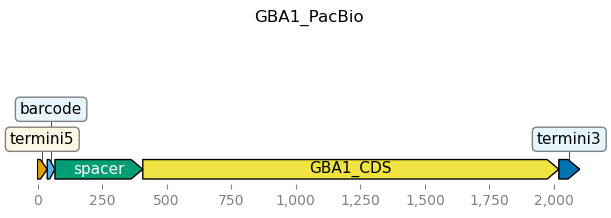

In [8]:
fig = targets.plot(ax_width=7,
                   plots_indexing='biopython',  # numbering starts at 0
                   ax_height=2,  # height of each plot
                   hspace=1.2,  # vertical space between plots
                   )

plotfile = os.path.join(config['figs_dir'], 'amplicon.pdf')
print(f"Saving plot to {plotfile}")
fig.savefig(plotfile, bbox_inches='tight')

Write out the specs used to parse the features

In [9]:
print(targets.feature_parse_specs('yaml'))

GBA1_PacBio:
  query_clip5: 38
  query_clip3: 76
  termini5:
    filter:
      clip5: 38
      mutation_nt_count: 10
      mutation_op_count: null
      clip3: 0
    return: []
  GBA1_CDS:
    filter:
      mutation_nt_count: 30
      mutation_op_count: null
      clip5: 0
      clip3: 0
    return:
    - mutations
    - accuracy
  spacer:
    filter:
      mutation_nt_count: 10
      mutation_op_count: null
      clip5: 0
      clip3: 0
    return:
    - mutations
    - accuracy
  barcode:
    return:
    - sequence
    - accuracy
    filter:
      clip5: 0
      clip3: 0
      mutation_nt_count: 0
      mutation_op_count: 0
  termini3:
    filter:
      clip3: 76
      mutation_nt_count: 10
      mutation_op_count: null
      clip5: 0
    return: []



load alignments files

In [10]:
aligned=pd.read_csv(config['aligned_CCSs'], keep_default_na=False)
filtered=pd.read_csv(config['filtered_CCSs'], keep_default_na=False)
aligned

,name,library,run,query_name,query_clip5,query_clip3,GBA1_CDS_mutations,GBA1_CDS_accuracy,spacer_mutations,spacer_accuracy,barcode_sequence,barcode_accuracy
0,GBA1,GBA1,first,m84140_250314_170434_s1/243340833/ccs,0,4,C1268G C1269G,1.000000,,1.000000,GTCCCATGAGGTAAATAACACAACTCAGTT,1.000000
1,GBA1,GBA1,first,m84140_250314_170434_s1/245632389/ccs,0,4,T33C del198to198 G477T C564T del661to661 del84...,0.983626,del261to261 del326to326,0.982271,GGTCAGCACACAACTCAGCGACGTTCAGGC,0.988590
2,GBA1,GBA1,first,m84140_250314_170434_s1/242618567/ccs,0,4,A274T T275G G276T,0.999786,ins326G,0.999995,GCTCAAGCCCGCGGGGGCGTCCCTTGAAGC,0.999472
3,GBA1,GBA1,first,m84140_250314_170434_s1/264768663/ccs,0,4,A274T T275G G276T,1.000000,,1.000000,TTGCCCTTGAGGGAAACCCGCGACTGGCAA,1.000000
4,GBA1,GBA1,first,m84140_250314_170434_s1/260511187/ccs,0,3,A274T T275G G276T,1.000000,,1.000000,TGATCGATAAGGGGCGTCCCGCGACCCTAG,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...
7410182,GBA1,GBA1,first,m84140_250314_170434_s1/7411203/ccs,0,4,del354to354 C880G A881G T882G del1135to1135,0.994170,,0.994105,CGCATGTTATTGCGGCGATTGATCTTAATC,0.999830
7410183,GBA1,GBA1,first,m84140_250314_170434_s1/80547586/ccs,0,4,del693to694 A697G G699A del711to711 T859G G860...,0.985651,del88to88 del230to230,0.983845,CACACAATCTCCACTTTTTCTGTCAGTAAC,0.999180
7410184,GBA1,GBA1,first,m84140_250314_170434_s1/158667419/ccs,0,4,del7to7 del136to136 del342to342 del409to409 in...,0.974130,del59to59 T88G C206A ins301G,0.985703,GGGAAATCTAGCCATTTACATCTTACGCCG,0.997833
7410185,GBA1,GBA1,first,m84140_250314_170434_s1/202707181/ccs,0,4,ins20C ins27G A884C G885T del982to982 A1034T d...,0.976550,,0.995132,TACCAACAAGCACGCCGTACTGCCATTATA,0.988898


In [11]:
len(aligned), len(filtered)

(7410187, 1254675)

In [12]:
filtered


,name,library,run,query_name,filter_reason
0,GBA1,GBA1,first,m84140_250314_170434_s1/256642654/ccs,query_clip5
1,GBA1,GBA1,first,m84140_250314_170434_s1/266276482/ccs,query_clip5
2,GBA1,GBA1,first,m84140_250314_170434_s1/256774426/ccs,query_clip5
3,GBA1,GBA1,first,m84140_250314_170434_s1/250220488/ccs,query_clip5
4,GBA1,GBA1,first,m84140_250314_170434_s1/243930650/ccs,barcode mutation_nt_count
...,...,...,...,...,...
1254670,GBA1,GBA1,first,m84140_250314_170434_s1/52366753/ccs,GBA1_CDS clip5
1254671,GBA1,GBA1,first,m84140_250314_170434_s1/58396769/ccs,GBA1_CDS clip5
1254672,GBA1,GBA1,first,m84140_250314_170434_s1/58136265/ccs,GBA1_CDS clip5
1254673,GBA1,GBA1,first,m84140_250314_170434_s1/70587871/ccs,GBA1_CDS clip5


In [13]:
aligned=pd.read_csv(config['aligned_CCSs'], keep_default_na=False)
filtered=pd.read_csv(config['filtered_CCSs'], keep_default_na=False)

#aligned['name']='insr'
#aligned['target']='GBA1_PacBio_amplicon'

#aligned=aligned[['name','library','run','query_name', 'query_clip5', 'query_clip3', 'gene_mutations',
#       'gene_accuracy', 'barcode_sequence', 'barcode_accuracy','target']]

#filtered=filtered.groupby(['filter_reason']).size().reset_index(name='count').sort_values(['count'], ascending=False)
#filtered['name']='insr'
#filtered['target']='GBA1_PacBio_amplicon'




#d = {'name': 'insr', 'library':'insr', 'run': 'first', 'category':['aligned IR_Pb_amplicon', 'filtered IR_Pb_amplicon','unmapped'], 'count':[3568566,309112,139229] }
#readstats = pd.DataFrame(data=d)

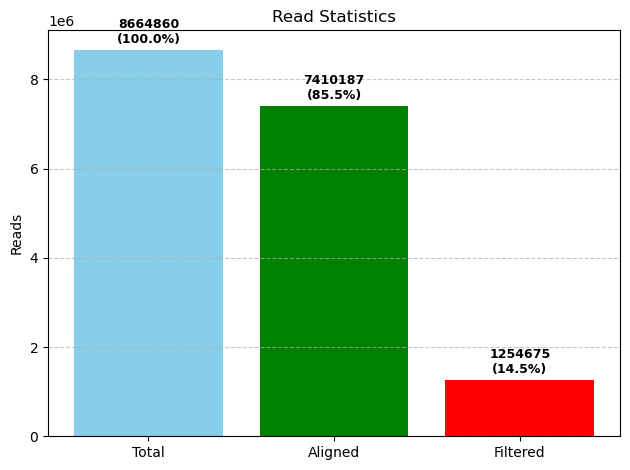

In [14]:
total_reads = (len(aligned) + len(filtered))-2 #minus the header
aligned_reads = len(aligned)
filtered_reads = len(filtered)



total_reads = (len(aligned) + len(filtered)) - 2  # minus the header
aligned_reads = len(aligned)
filtered_reads = len(filtered)

# Values and labels
values = [total_reads, aligned_reads, filtered_reads]
labels = ['Total', 'Aligned', 'Filtered']

# Plot
plt.bar(labels, values, color=['skyblue', 'green', 'red'])
plt.ylabel('Reads')
plt.title('Read Statistics')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add text on top of bars
for i, v in enumerate(values):
    percentage = v / total_reads * 100
    plt.text(i, v + total_reads*0.01, f'{v}\n({percentage:.1f}%)', 
             ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()



Reorder filter dataframe by count for plotting


In [15]:
filter_reason_list = filtered['filter_reason'].value_counts().index.tolist()
filter_reason_cat = pd.Categorical(filtered['filter_reason'], categories=filter_reason_list)
filtered = filtered.assign(filter_reason_cat = filter_reason_cat)

plot the filtering reason for all runs:

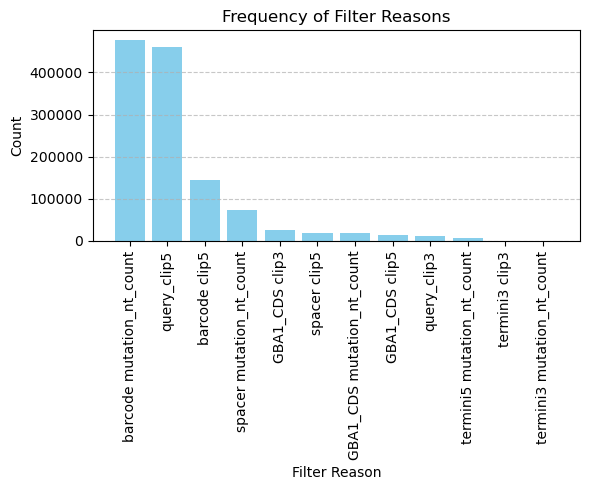

In [16]:

# Count frequency of each unique reason
reason_counts = filtered['filter_reason'].value_counts()

# Plot
plt.figure(figsize=(0.5 * len(reason_counts), 5))  # dynamic width based on number of reasons
plt.bar(reason_counts.index, reason_counts.values, color='skyblue')
plt.xlabel('Filter Reason')
plt.ylabel('Count')
plt.title('Frequency of Filter Reasons')
plt.xticks(rotation=90)  # rotate x-axis labels
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


Read parsed alignments into a data frame and save as processed CCSs

In [17]:
aligned_df = (aligned.drop(columns=['query_clip5', 'query_clip3', 'run','name'])
              .rename(columns={'barcode_sequence': 'barcode'}))

print(f"First few lines of information on the parsed alignments:")
display(HTML(aligned_df.head().to_html(index=False)))

aligned_df.to_csv(config['processed_ccs_file'], index=False)

print("\nBarcodes and mutations for valid processed CCSs "
      f"have been written to {config['processed_ccs_file']}.")

First few lines of information on the parsed alignments:


library,query_name,GBA1_CDS_mutations,GBA1_CDS_accuracy,spacer_mutations,spacer_accuracy,barcode,barcode_accuracy
GBA1,m84140_250314_170434_s1/243340833/ccs,C1268G C1269G,1.000000,,1.000000,GTCCCATGAGGTAAATAACACAACTCAGTT,1.000000
GBA1,m84140_250314_170434_s1/245632389/ccs,T33C del198to198 G477T C564T del661to661 del849to849 T1249A,0.983626,del261to261 del326to326,0.982271,GGTCAGCACACAACTCAGCGACGTTCAGGC,0.988590
GBA1,m84140_250314_170434_s1/242618567/ccs,A274T T275G G276T,0.999786,ins326G,0.999995,GCTCAAGCCCGCGGGGGCGTCCCTTGAAGC,0.999472
GBA1,m84140_250314_170434_s1/264768663/ccs,A274T T275G G276T,1.000000,,1.000000,TTGCCCTTGAGGGAAACCCGCGACTGGCAA,1.000000
GBA1,m84140_250314_170434_s1/260511187/ccs,A274T T275G G276T,1.000000,,1.000000,TGATCGATAAGGGGCGTCCCGCGACCCTAG,1.000000



Barcodes and mutations for valid processed CCSs have been written to results/process_ccs/processed_ccs.csv.


# Get processed CCSs

Read the processed CCSs into a data frame:

In [18]:
processed_ccs = pd.read_csv(config['processed_ccs_file'], na_filter=None)

print(f"Loaded {len(processed_ccs)} CCSs, here are the first few lines:.")

display(HTML(processed_ccs.head().to_html(index=False)))

Loaded 7410187 CCSs, here are the first few lines:.


library,query_name,GBA1_CDS_mutations,GBA1_CDS_accuracy,spacer_mutations,spacer_accuracy,barcode,barcode_accuracy
GBA1,m84140_250314_170434_s1/243340833/ccs,C1268G C1269G,1.000000,,1.000000,GTCCCATGAGGTAAATAACACAACTCAGTT,1.000000
GBA1,m84140_250314_170434_s1/245632389/ccs,T33C del198to198 G477T C564T del661to661 del849to849 T1249A,0.983626,del261to261 del326to326,0.982271,GGTCAGCACACAACTCAGCGACGTTCAGGC,0.988590
GBA1,m84140_250314_170434_s1/242618567/ccs,A274T T275G G276T,0.999786,ins326G,0.999995,GCTCAAGCCCGCGGGGGCGTCCCTTGAAGC,0.999472
GBA1,m84140_250314_170434_s1/264768663/ccs,A274T T275G G276T,1.000000,,1.000000,TTGCCCTTGAGGGAAACCCGCGACTGGCAA,1.000000
GBA1,m84140_250314_170434_s1/260511187/ccs,A274T T275G G276T,1.000000,,1.000000,TGATCGATAAGGGGCGTCCCGCGACCCTAG,1.000000


Overall statistics on number of total CCSs and number of unique barcodes:

In [19]:
# Compute total CCSs and unique barcodes
total_CCSs = processed_ccs['barcode'].size
unique_barcodes = processed_ccs['barcode'].nunique()

# Compute average CCSs per barcode
avg_CCSs_per_barcode = total_CCSs / unique_barcodes

# Create a summary DataFrame
summary = pd.DataFrame({
    'total_CCSs': [total_CCSs],
    'unique_barcodes': [unique_barcodes],
    'avg_CCSs_per_barcode': [round(avg_CCSs_per_barcode, 2)]
})

# Display the summary table
display(HTML(summary.to_html(index=False)))

total_CCSs,unique_barcodes,avg_CCSs_per_barcode
7410187,320004,23.16


## Filter processed CCSs based on sequencing accuracy

PacBio ccs program's estimated "accuracy" for both the barcode and the gene sequence for each processed CCSs. 

It is visually easier to look at the error rate which is one minus the accurry. To plot on a log scale (which can't show error rates of zero), error_rate_floor is defined, and set all error rates less than this to that value:

In [20]:
error_rate_floor = 1e-7  # error rates < this set to this
if error_rate_floor >= config['max_error_rate']:
    raise ValueError('error_rate_floor must be < max_error_rate')

processed_ccs = (
    processed_ccs
    .assign(barcode_error=lambda x: numpy.clip(1 - x['barcode_accuracy'],
                                               error_rate_floor, None),
            gene_error=lambda x: numpy.clip(1 - x['GBA1_CDS_accuracy'],
                                            error_rate_floor, None)
            )
    )

Plot the error rates, drawing a dashed vertical line at the threshold (1e-4) separating the CCSs that will be retained for consensus building versus those that will be discarded:

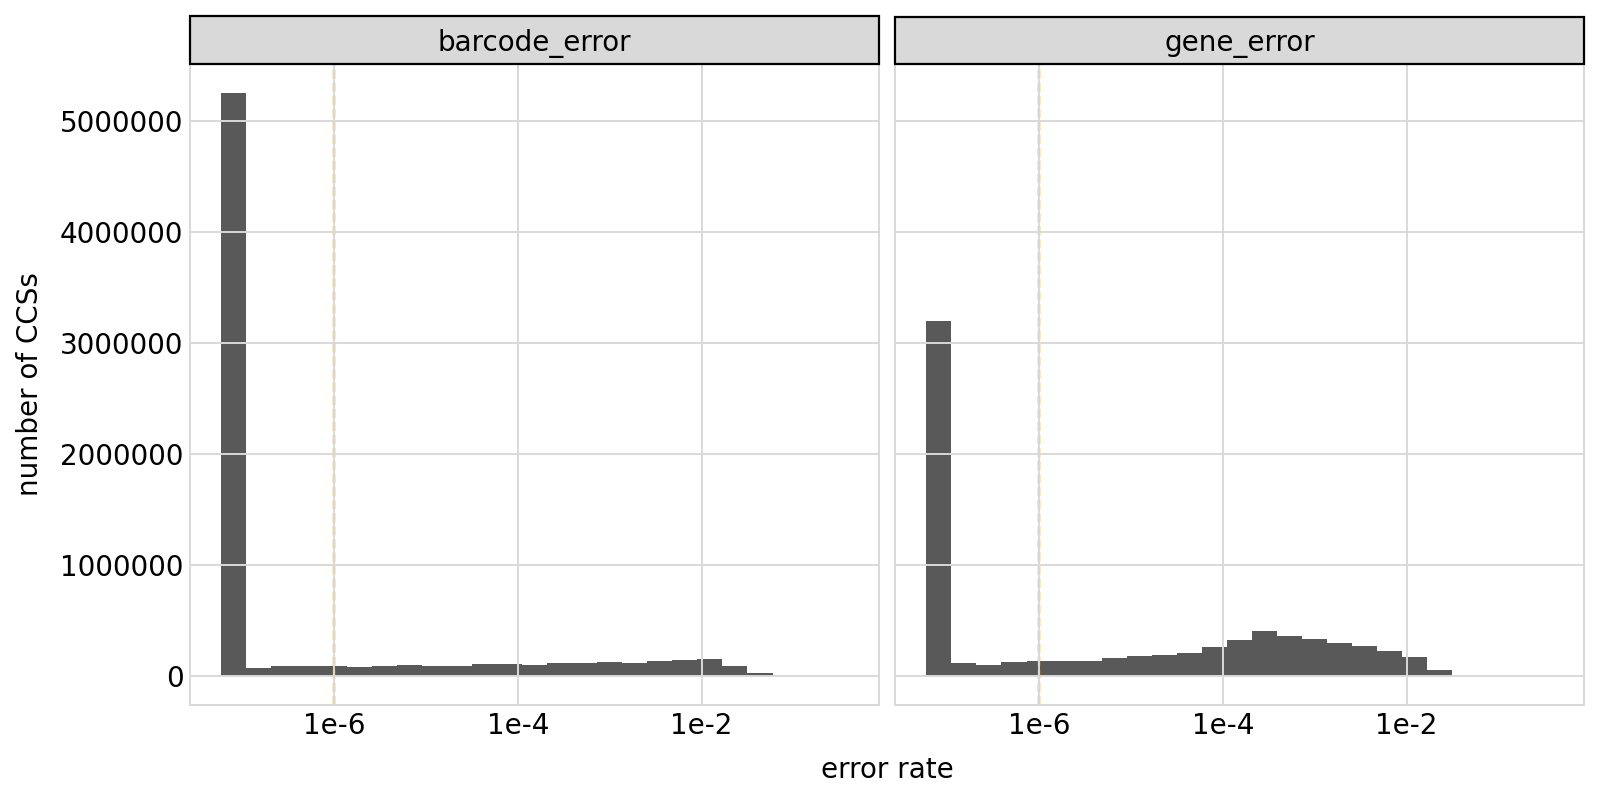

In [21]:
p = (
 ggplot(processed_ccs
        .melt(value_vars=['barcode_error', 'gene_error'],
              var_name='feature_type', value_name='error rate'),
        aes('error rate')) +
 geom_histogram(bins=25) +
 geom_vline(xintercept=config['max_error_rate'],
            linetype='dashed',
            color=CBPALETTE[1]) +
 facet_wrap('~ feature_type') +
 theme(figure_size=(8, 4)) +
 ylab('number of CCSs') +
 scale_x_log10()
 )
display(p)

Retain the CCSs that pass the filters

In [22]:
processed_ccs = processed_ccs.assign(
    retained=lambda x: (
        (x["gene_error"] <= config['max_error_rate']) & (x["barcode_error"] <= config['max_error_rate'])
    )
)

(
    processed_ccs.groupby(["library", "retained"])
    .size()
    .rename("number of CCSs")
    .reset_index()
)

,library,retained,number of CCSs
0,GBA1,False,3840964
1,GBA1,True,3569223


## Sequences per barcode

How many times is each barcode sequenced? This is useful to know for thinking about building the barcode consensus.

Plot the distribution of the number of times each barcode is observed among the retained CCs:

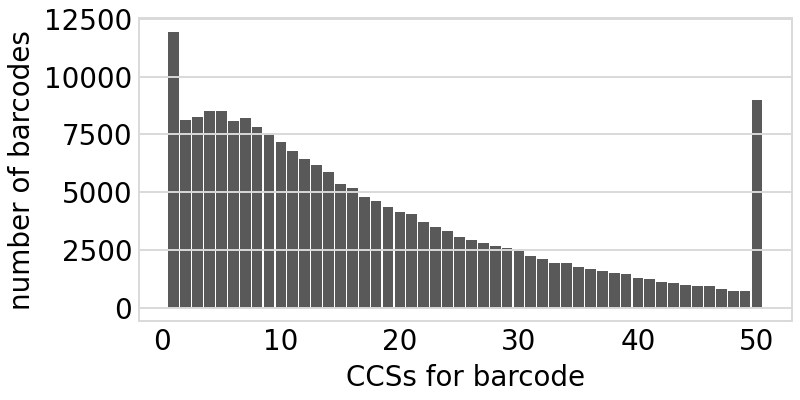

Total barcodes: 203778
Barcodes with 1 CCS read: 11945 (5.9%)
Barcodes with ≥2 CCS reads: 191833 (94.1%)


In [23]:
max_count = 50 # in plot, group all barcodes with >= this many counts

p = (
 ggplot(
    processed_ccs
     .query('retained')
     .groupby(['library', 'barcode'])
     .size()
     .rename('nseqs')
     .reset_index()
     .assign(nseqs=lambda x: numpy.clip(x['nseqs'], None, max_count)),
    aes('nseqs')) +
 geom_bar() +
 theme(figure_size=(4 , 2),
       panel_grid_major_x=element_blank(),
       ) +
 ylab('number of barcodes') +
 xlab('CCSs for barcode')
 )

display(p)

barcode_counts = (
    processed_ccs
    .query('retained')
    .groupby(['library', 'barcode'])
    .size()
    .rename('nseqs')
    .reset_index()
)

n_total = len(barcode_counts)
n_single = (barcode_counts['nseqs'] == 1).sum()
n_multi = (barcode_counts['nseqs'] >= 2).sum()

print(f'Total barcodes: {n_total}')
print(f'Barcodes with 1 CCS read: {n_single} ({n_single / n_total * 100:.1f}%)')
print(f'Barcodes with \u22652 CCS reads: {n_multi} ({n_multi / n_total * 100:.1f}%)')

Now, plot the distribution of the number of sequences with barcodes that are observed a given number of time (again among retained CCSs). This plot differs from the one above because if a barcode is observed multiple times it is given one count in the barcode-count plot above (which tallies barcodes) but multiple counts in the sequence-count plot below:

## Empirical accuracy of CCSs

Rather than relying on the PacBio's ccs accuracy, an empirical accuracy of the sequences is estimated as described [here](https://jbloomlab.github.io/alignparse/alignparse.consensus.html) by looking at all instances of multiple sequences of the same barcode and determining how often they are identical. 


First, the sequences with indels are flagged

In [24]:
processed_ccs = alignparse.consensus.add_mut_info_cols(processed_ccs,
                                                       mutation_col='GBA1_CDS_mutations',
                                                       n_indel_col='n_indels')

processed_ccs = processed_ccs.assign(has_indel=lambda x: x['n_indels'] > 0)

Plot how many sequences have indels:

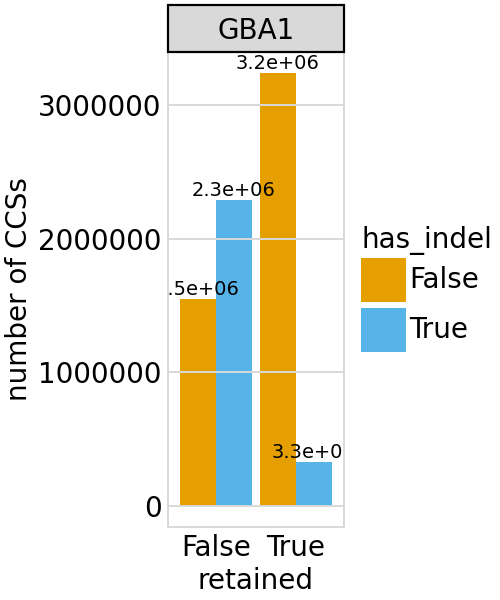

In [25]:
p = (
 ggplot(processed_ccs,
        aes('retained', fill='has_indel')) +
 geom_bar(position='dodge') +
 geom_text(aes(label='..count..'), stat='count', va='bottom', size=7,
           position=position_dodge(width=0.9), format_string='{:.2g}') +
 theme(figure_size=(2.5, 3),
       panel_grid_major_x=element_blank(),
       ) +
 ylab('number of CCSs') +
 scale_fill_manual(values=CBPALETTE[1:]) +
 facet_wrap('~ library', nrow=1))

display(p)

Get the empirical accuracy for each of the CCSs groups displayed above:

In [26]:
high_acc = config['max_error_rate'] / 9.9
empirical_acc = []

for desc, query_str in [
        ('retained', 'retained'),
        ('retained, no indel', 'retained and not has_indel'),
        ('10X accuracy',
         f"(gene_error < {high_acc}) and (barcode_error < {high_acc})"),
        ('10X accuracy, no indel',
         f"(gene_error < {high_acc}) and (barcode_error < {high_acc}) and not has_indel")
        ]:
    # get just CCSs in that category
    df = processed_ccs.query(query_str)
    
    # compute empirical accuracy
    empirical_acc.append(
        alignparse.consensus.empirical_accuracy(df,
                                                mutation_col='GBA1_CDS_mutations')
        .assign(description=desc)
        .merge(df
               .groupby('library')
               .size()
               .rename('number_CCSs')
               .reset_index()
               )
        )

# make description categorical to preserve order, and annotate as "actual"
# the category ("retained, no indel") that we will use for building variants.
empirical_acc = (
    pd.concat(empirical_acc, ignore_index=True, sort=False)
    .assign(description=lambda x: pd.Categorical(x['description'],
                                                 x['description'].unique(),
                                                 ordered=True),
            actual=lambda x: numpy.where(x['description'] == 'retained, no indel',
                                         True, False),
            )
    )

display(HTML(empirical_acc.to_html(index=False)))

library,accuracy,description,number_CCSs,actual
GBA1,0.915694,retained,3569223,False
GBA1,0.998406,"retained, no indel",3242127,True
GBA1,0.930121,10X accuracy,3135777,False
GBA1,0.998525,"10X accuracy, no indel",2894201,False


Plot the empirical accuracies, using a different color to show the category that will be used for the next steps:

Saving plot to results/figures/empirical_CCS_accuracy.pdf


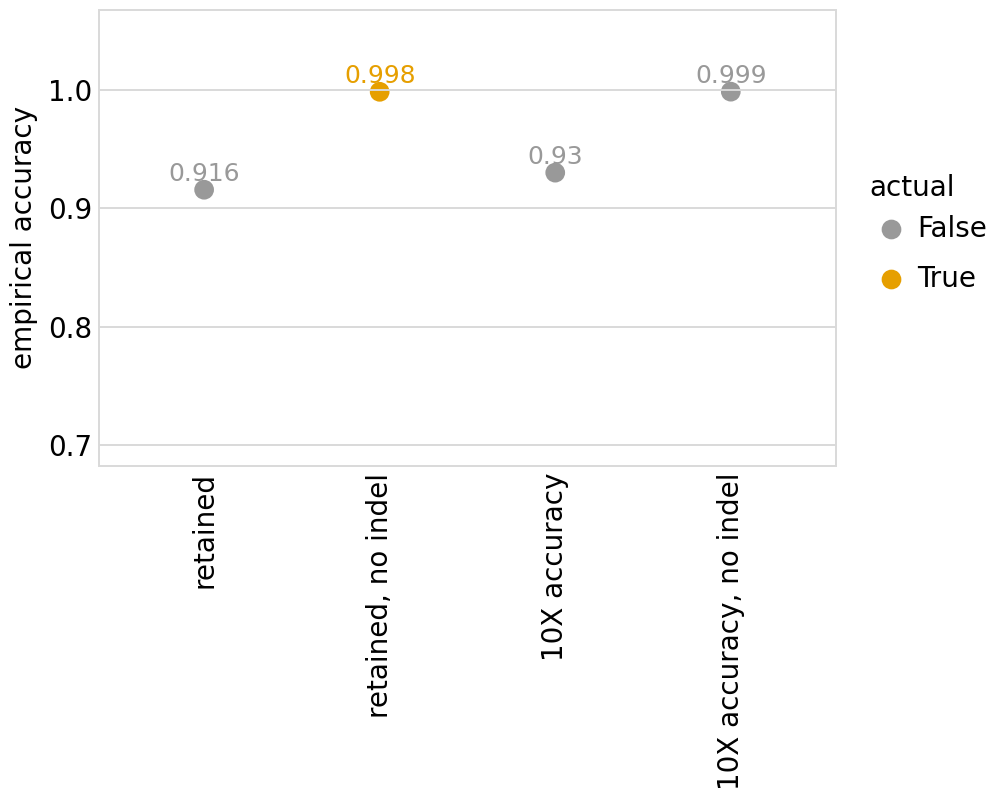

In [27]:

p = (
    ggplot(empirical_acc,
           aes('description', 'accuracy', color='actual', label='accuracy')
           ) +
    geom_point(size=3) +
    geom_text(va='bottom', size=9, format_string='{:.3g}', nudge_y=0.003) +
    theme(
        figure_size=(5, 4),
        axis_text_x=element_text(angle=90),
        panel_grid_major_x=element_blank(),
    ) +
    xlab('') +
    scale_y_continuous(name='empirical accuracy', limits=(0.7, 1.05)) +
    scale_color_manual(values=CBPALETTE)  # Removed guide=False here
)

# File path for saving the plot
plotfile = os.path.join(config['figs_dir'], 'empirical_CCS_accuracy.pdf')
print(f"Saving plot to {plotfile}")

# Display plot
display(p)


The above analysis shows that by excluding sequences with indels the accuracy of each CCS is around 99.4%. There is no higher empirical accuracy by imposing a more stringent filter from the PacBio ccs program.

Note that this empirical accuracy is for a single CCS. For barcodes with multiple CCS, the actual accuracy of the consensus sequences will be higher than the empirical accuracy above due to capturing information from multiple CCSs.

## Consensus sequences for barcodes

First, call the consensus for each barcode including all retained sequences, even those with indels using the simple method implemented in alignparse.consensus.simple_mutconsensus which works like this:

1. When there is just one CCS per barcode, the consensus is just that sequence.
2. When there are multiple CCSs per barcode, they are used to build a consensus--however, the entire barcode is discarded if there are many differences between CCSs with the barcode, or high-frequency non-consensus mutations. 

In [28]:
consensus, dropped = alignparse.consensus.simple_mutconsensus(
                        processed_ccs.query('retained'),
                        group_cols=('barcode'),
                        mutation_col='GBA1_CDS_mutations',
                        )

First few lines of consensus sequences data frame for each barcode. variant_call_support is indicating how many CCSs support the variant call

In [29]:
display(HTML(consensus.head().to_html(index=False)))

barcode,GBA1_CDS_mutations,variant_call_support
AAAAAAAAAAAGACGACGTGCAGTCCGCTT,,1
AAAAAAAAAATGATAGGGTCGATACATGGT,G233A C234G,1
AAAAAAAAACGACATCCGCGCAGCGACTTA,,13
AAAAAAAACAGGCAAGTAGCAGTTTTGCCT,A139T C141G,8
AAAAAAAACGGGGGGTTGACAGCTAAACAA,,44


Since only variants with substitutions and without indels are retained, information about substitution and number of indels added to the consensus table

In [30]:
consensus = alignparse.consensus.add_mut_info_cols(
                    consensus,
                    mutation_col='GBA1_CDS_mutations',
                    sub_str_col='substitutions',
                    n_indel_col='number_of_indels',
                    overwrite_cols=True)

display(HTML(consensus.head(100).to_html(index=False)))

barcode,GBA1_CDS_mutations,variant_call_support,substitutions,number_of_indels
AAAAAAAAAAAGACGACGTGCAGTCCGCTT,,1,,0
AAAAAAAAAATGATAGGGTCGATACATGGT,G233A C234G,1,G233A C234G,0
AAAAAAAAACGACATCCGCGCAGCGACTTA,,13,,0
AAAAAAAACAGGCAAGTAGCAGTTTTGCCT,A139T C141G,8,A139T C141G,0
AAAAAAAACGGGGGGTTGACAGCTAAACAA,,44,,0
AAAAAAAACTCCGCCCCCAATGCTCTCAGC,,2,,0
AAAAAAAATCGTGTCGGTATTACTATATGC,,2,,0
AAAAAAACAGGCACGGTTTCCACTGGATCT,,1,,0
AAAAAAACATCCCTGTAGGTGCTGAACGTT,G523A C524G A525G,29,G523A C524G A525G,0
AAAAAAACGGGGGGGTTGACAGCTAAACAA,,1,,0


Plot distribution of number of CCSs supporting each variant call (consensus), indicating whether or not there is an indel:

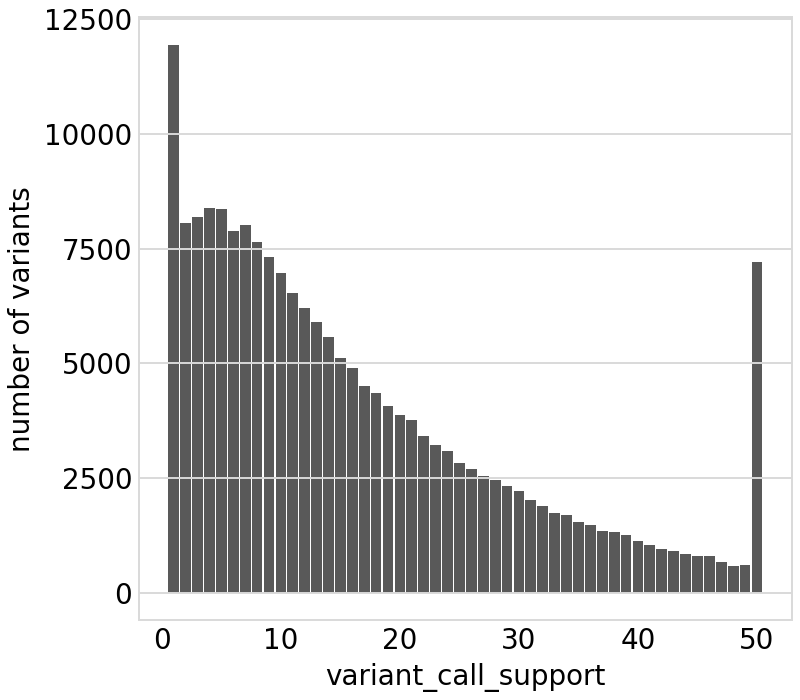

In [31]:
max_variant_call_support = 50  # group variants with >= this much support

p = (
 ggplot(consensus
        .assign(variant_call_support=lambda x: numpy.clip(x['variant_call_support'],
                                                          None,
                                                          max_variant_call_support),
                indel_state=lambda x: numpy.where(x['number_of_indels'] > 0,
                                                  'has indel', 'no indel')
                ),
        aes('variant_call_support')) +
 geom_bar() +
 ylab('number of variants') +
 
 theme(figure_size=(4, 3.5),
       panel_grid_major_x=element_blank(),
       ) 
 )
display(p)

As the the above plots show, most variant consensus sequences do not have indels, especially the ones with multiple  supporting CCSs.

All consensus sequences with indels will be dropped from the variant-barcode lookup table as we are interested in point mutations rather than indels. 

Here are number of valid consensus sequences, no indels:

In [32]:
print(f"number of valid consensus sequences is: {len(consensus.query('number_of_indels == 0'))}")

number of valid consensus sequences is: 189501


In [33]:
consensus

,barcode,GBA1_CDS_mutations,variant_call_support,substitutions,number_of_indels
0,AAAAAAAAAAAGACGACGTGCAGTCCGCTT,,1,,0
1,AAAAAAAAAATGATAGGGTCGATACATGGT,G233A C234G,1,G233A C234G,0
2,AAAAAAAAACGACATCCGCGCAGCGACTTA,,13,,0
3,AAAAAAAACAGGCAAGTAGCAGTTTTGCCT,A139T C141G,8,A139T C141G,0
4,AAAAAAAACGGGGGGTTGACAGCTAAACAA,,44,,0
...,...,...,...,...,...
192372,TTTTTTTCGGATTTTACCATCACTCCGCCT,G251A T252G,29,G251A T252G,0
192373,TTTTTTTGAGAACAGCGCTATCCCAACTCA,,11,,0
192374,TTTTTTTTAAGTGCTTCTACTATCTATCCC,,9,,0
192375,TTTTTTTTGTCTCGTAATAAAACCAGCCCT,G307A C309G,46,G307A C309G,0


Write the retained consensus sequences to a CSV file that links the nucleotide mutations to the barcodes:

In [34]:
print(f"Writing nucleotide variants to {config['nt_variant_table_file']}")

consensus['library'] = 'GBA1'

(consensus
 [['barcode', 'substitutions', 'variant_call_support','number_of_indels', 'library']]
 .to_csv(config['nt_variant_table_file'], index=False)
 )
      
print('Here are the first few lines of this file:')
display(HTML(
    pd.read_csv(config['nt_variant_table_file'], na_filter=None)
    .head()
    .to_html(index=False)
    ))

Writing nucleotide variants to results/variants/nucleotide_variant_table.csv
Here are the first few lines of this file:


barcode,substitutions,variant_call_support,number_of_indels,library
AAAAAAAAAAAGACGACGTGCAGTCCGCTT,,1,0,GBA1
AAAAAAAAAATGATAGGGTCGATACATGGT,G233A C234G,1,0,GBA1
AAAAAAAAACGACATCCGCGCAGCGACTTA,,13,0,GBA1
AAAAAAAACAGGCAAGTAGCAGTTTTGCCT,A139T C141G,8,0,GBA1
AAAAAAAACGGGGGGTTGACAGCTAAACAA,,44,0,GBA1


What happened to the barcodes that we "dropped" because we could not construct a reliable consensus? The dropped data frame from alignparse.consensus.simple_mutconsensus has this information:

number of the barcodes that dropped due to unreliable consensus: 11401       
here are the first few lines with summarised plots:



barcode,drop_reason,nseqs
AAAAAACGCTGGCAACTCCCTCCAAGGCAC,subs diff too large,24
AAAAAAGGTGGGATAACGCTAAGATGACCG,subs diff too large,39
AAAAACTTTTTGAAGTACCTAAAAGGGATT,subs diff too large,8
AAAAATCCTACGGGCCGTCAACCGCTAATG,indels diff too large,68
AAAAATTGTAGGGTCCAGGTTCTATCAATG,subs diff too large,27


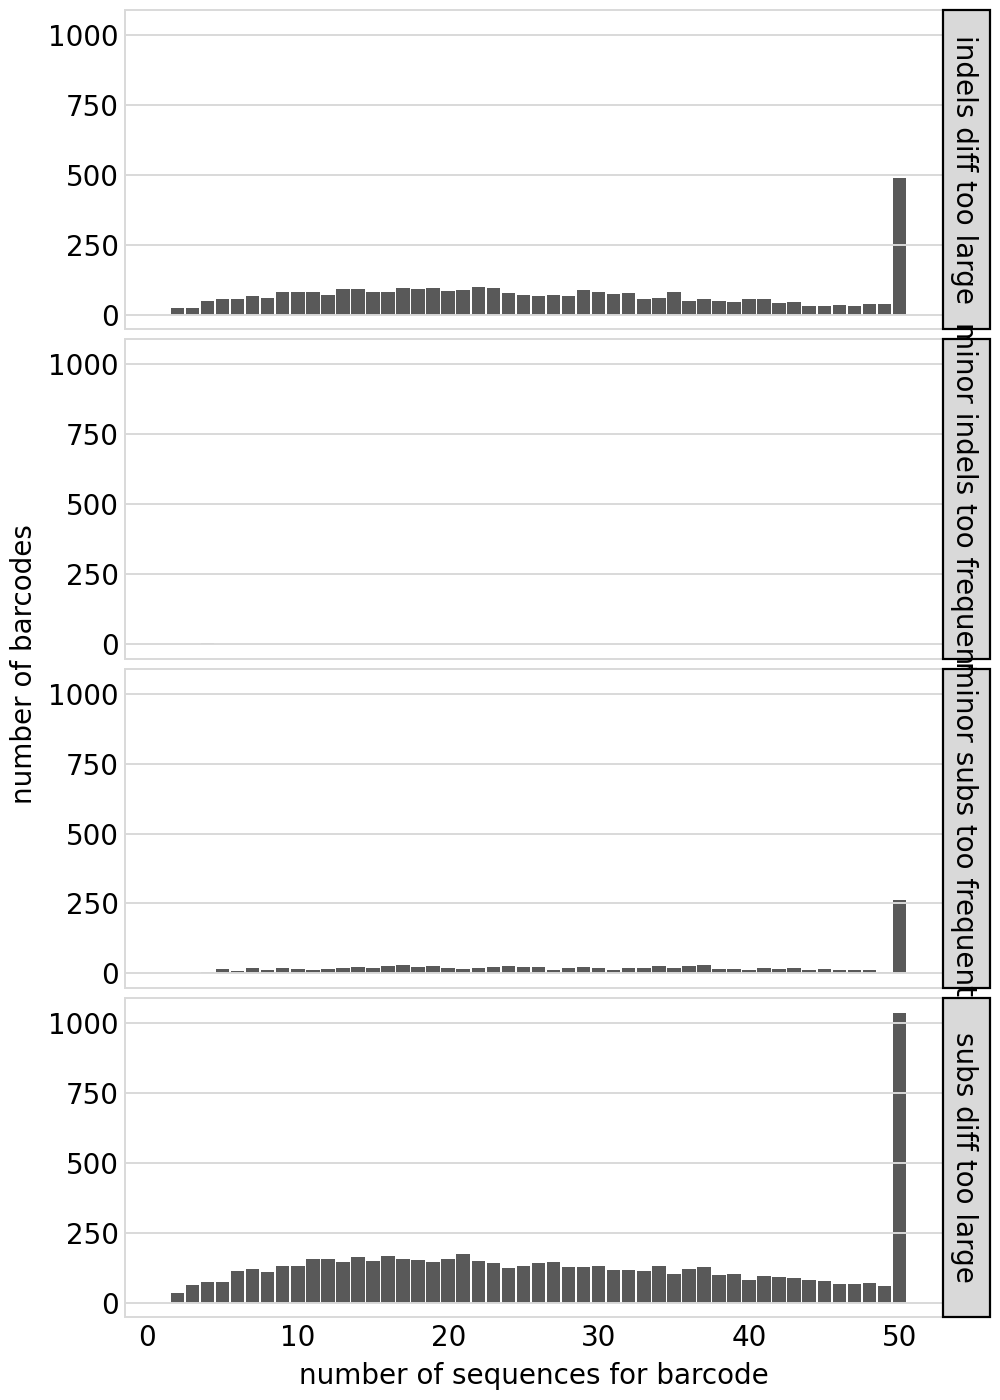

In [35]:
print(f"number of the barcodes that dropped due to unreliable consensus: {len(dropped)} \
      \nhere are the first few lines with summarised plots:\n")

(display(HTML(dropped.head().to_html(index=False))))


max_nseqs = 50  # plot together all barcodes with >= this many sequences

p = (
 ggplot(
    dropped.assign(nseqs=lambda x: numpy.clip(x['nseqs'], None, max_nseqs)),
    aes('nseqs')) + 
 geom_bar() + 
 scale_x_continuous(limits=(1, None)) +
 xlab('number of sequences for barcode') +
 ylab('number of barcodes') +
 facet_grid('drop_reason') +
 theme(figure_size=(5,7),
       panel_grid_major_x=element_blank(),
       )
 )
display(p)

## Create barcode-variant table

Create a CodonVariantTable that stores and processes all the information about the variant consensus sequences. 

First read the PacBio amplicon target sequence:

In [36]:
targets = alignparse.targets.Targets(seqsfile=config['amplicons'],
                                     feature_parse_specs=config['feature_parse_specs'])
geneseq = targets.get_target(config['primary_target']).get_feature('GBA1_CDS').seq

print(f"Read {len(geneseq)} nts for {config['primary_target']} from {config['amplicons']}")

Read 1611 nts for GBA1_PacBio from input_files/GBA1_PacBio.gb


Now initialise the codon variant table using this amplicon sequence and list of nucleotide mutations for each variant:

In [37]:
variants = dms_variants.codonvarianttable.CodonVariantTable(
                barcode_variant_file=config['nt_variant_table_file'],
                geneseq=geneseq,
                extra_cols=['number_of_indels']
                )

## Basic stats on variants

In [38]:
df=variants.barcode_variant_df.copy()

print ("Number of variants for the amplicon is:")
print (len(df))

print ("\nNumber of variants for the amplicon excluding indels:")
print (len(df[df['number_of_indels']==0]))

print ("\nbarcodes with consensus seqeunces (no_indels with zero or single aa changes)")
print (len(df[(df['number_of_indels']==0) & (df['n_aa_substitutions'] < 2) ]))

print ("\nbarcodes with single_aa_substitutions (nonsynonymous)")
print (len(df[(df['number_of_indels']==0) & (df['n_aa_substitutions']==1)]))

print ("\nbarcodes with WT sequence, no mutagenesis")
print (len(df[(df['number_of_indels']==0) & (df['n_aa_substitutions']==0) & (df['n_codon_substitutions']==0)]))

print ("\nbarcodes with synonymous mutations")
print (len(df[(df['number_of_indels']==0) & (df['n_aa_substitutions']==0) & (df['n_codon_substitutions']>0)]))

print ("\nunique missense aa substitutions in the library (library completeness)")
print (len(np.unique(df[(df['number_of_indels'] == 0) & (df['n_aa_substitutions'] == 1)]['aa_substitutions'])))

print ("\nbarcodes with single_aa_substitutions (stop codon)")
print (len(df[(df['number_of_indels'] == 0) &
    (df['n_aa_substitutions'] == 1) &
    (df['aa_substitutions'].str.endswith('*'))
]['aa_substitutions']))


print ("\nunique stop variants in the library")
print (df[(df['number_of_indels'] == 0) &
    (df['n_aa_substitutions'] == 1) &
    (df['aa_substitutions'].str.endswith('*'))
]['aa_substitutions'].nunique())



Number of variants for the amplicon is:
192377

Number of variants for the amplicon excluding indels:
189501

barcodes with consensus seqeunces (no_indels with zero or single aa changes)
184878

barcodes with single_aa_substitutions (nonsynonymous)
123668

barcodes with WT sequence, no mutagenesis
54028

barcodes with synonymous mutations
7182

unique missense aa substitutions in the library (library completeness)
10460

barcodes with single_aa_substitutions (stop codon)
4896

unique stop variants in the library
526


In [39]:
((1608/3)*20)


10720.0

In [40]:
len('atggagttttcaagtccttccagagaggaatgtcccaagcctttgagtagggtaagcatcatggctggcagcctcacaggattgcttctacttcaggcagtgtcgtgggcatcaggtgcccgcccctgcatccctaaaagcttcggctacagctcggtggtgtgtgtctgcaatgccacatactgtgactcctttgaccccccgacctttcctgcccttggtaccttcagccgctatgagagtacacgcagtgggcgacggatggagctgagtatggggcccatccaggctaatcacacgggcacaggcctgctactgaccctgcagccagaacagaagttccagaaagtgaagggatttggaggggccatgacagatgctgctgctctcaacatccttgccctgtcaccccctgcccaaaatttgctacttaaatcgtacttctctgaagaaggaatcggatataacatcatccgggtacccatggccagctgtgacttctccatccgcacctacacctatgcagacacccctgatgatttccagttgcacaacttcagcctcccagaggaagataccaagctcaagatacccctgattcaccgagccctgcagttggcccagcgtcccgtttcactccttgccagcccctggacatcacccacttggctcaagaccaatggagcggtgaatgggaaggggtcactcaagggacagcccggagacatctaccaccagacctgggccagatactttgtgaagttcctggatgcctatgctgagcacaagttacagttctgggcagtgacagctgaaaatgagccttctgctgggctgttgagtggataccccttccagtgcctgggcttcacccctgaacatcagcgagacttcattgcccgtgacctaggtcctaccctcgccaacagtactcaccacaatgtccgcctactcatgctggatgaccaacgcttgctgctgccccactgggcaaaggtggtactgacagacccagaagcagctaaatatgttcatggcattgctgtacattggtacctggactttctggctccagccaaagccaccctaggggagacacaccgcctgttccccaacaccatgctctttgcctcagaggcctgtgtgggctccaagttctgggagcagagtgtgcggctaggctcctgggatcgagggatgcagtacagccacagcatcatcacgaacctcctgtaccatgtggtcggctggaccgactggaaccttgccctgaaccccgaaggaggacccaattgggtgcgtaactttgtcgacagtcccatcattgtagacatcaccaaggacacgttttacaaacagcccatgttctaccaccttggccacttcagcaagttcattcctgagggctcccagagagtggggctggttgccagtcagaagaacgacctggacgcagtggcactgatgcatcccgatggctctgctgttgtggtcgtgctaaaccgctcctctaaggatgtgcctcttaccatcaaggatcctgctgtgggcttcctggagacaatctcacctggctactccattcacacctacctgtggcgtcgccagtga')

1611

First, display the number of variants:

Plot the number of variants supported by each number of CCSs:

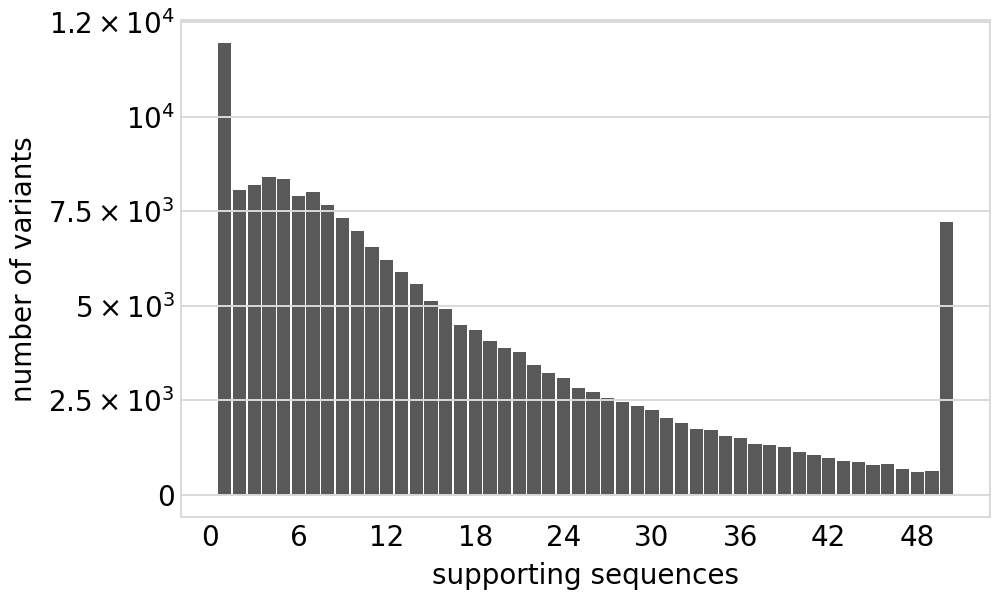

Saving plot to results/figures/supporting_sequences.pdf


In [41]:
max_support = 50  # group variants with >= this much support

p = variants.plotVariantSupportHistogram(max_support=max_support,
                                         widthscale=1.1,
                                         heightscale=0.9)
p = p + theme(panel_grid_major_x=element_blank(), figure_size=(5, 3))  # no vertical grid lines
p.draw()
display(p)

plotfile = os.path.join(config['figs_dir'], "supporting_sequences.pdf")
print(f"Saving plot to {plotfile}")
p.save(plotfile)

## Mutations per variant

Plot the number of barcoded variants with each number of amino-acid and codon mutations:

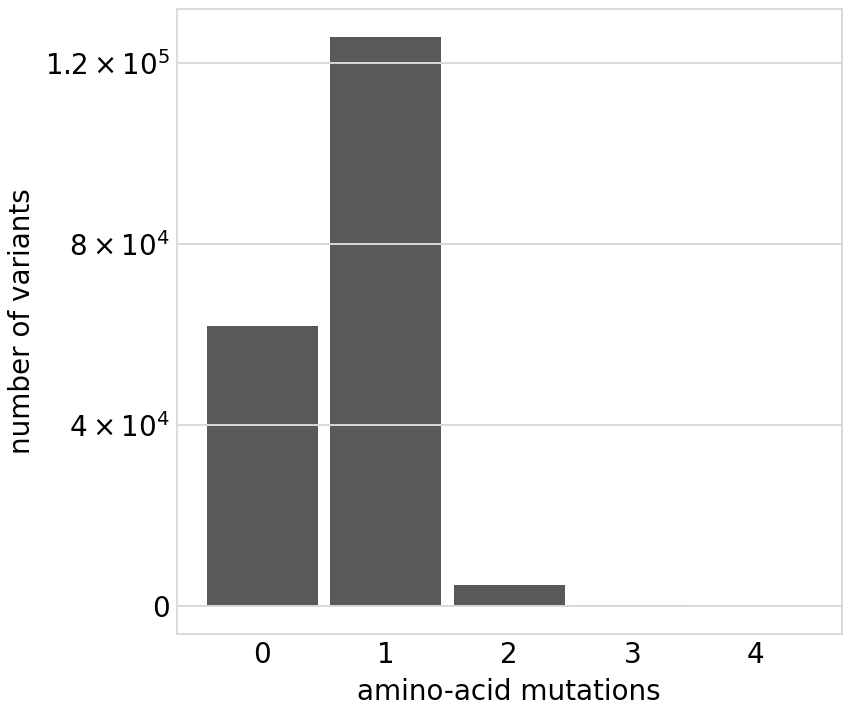

Saving plot to results/figures/n_aa_muts_per_variant.pdf


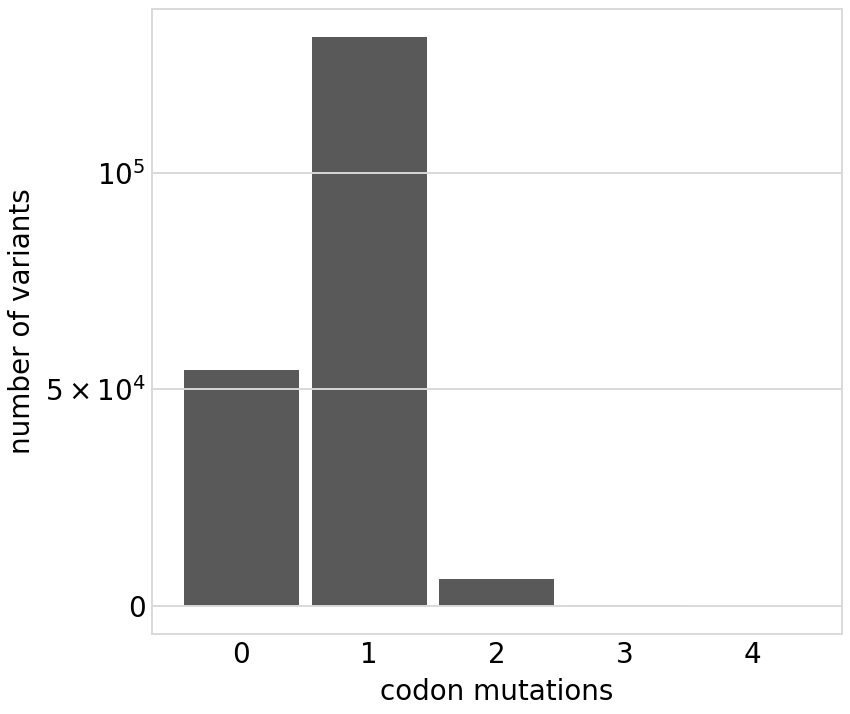

Saving plot to results/figures/n_codon_muts_per_variant.pdf


In [42]:
max_muts = 7  # group all variants with >= this many mutations

for mut_type in ['aa', 'codon']:
    p = variants.plotNumMutsHistogram(mut_type, samples=None, max_muts=max_muts,
                                      widthscale=1.7,
                                      heightscale=1.7)
    p = p + theme(panel_grid_major_x=element_blank())  # no vertical grid lines
    p.draw()
    display(p)
        
    plotfile = os.path.join(config['figs_dir'], f"n_{mut_type}_muts_per_variant.pdf")
    print(f"Saving plot to {plotfile}")
    p.save(plotfile)


In [43]:
def classify_variants(df):
    def classify(row):
        if row["n_codon_substitutions"] == 0:
            return "wildtype"
        elif row["n_codon_substitutions"] > 0 and row["n_aa_substitutions"] == 0:
            return "synonymous"
        elif "*" in str(row["aa_substitutions"]) and row["n_aa_substitutions"]==1:
            return "stop"
        elif row["n_aa_substitutions"] == 1:
            return "1 nonsynonymous"
        else:
            return ">1 nonsynonymous"
    variants.barcode_variant_df["variant_class"] = variants.barcode_variant_df.apply(classify, axis=1)
    return variants.barcode_variant_df


variants.barcode_variant_df=classify_variants(variants.barcode_variant_df)
variants.barcode_variant_df['aa_substitutions_c']=variants.barcode_variant_df['aa_substitutions'].where(variants.barcode_variant_df['aa_substitutions'] != '', variants.barcode_variant_df['variant_class'])


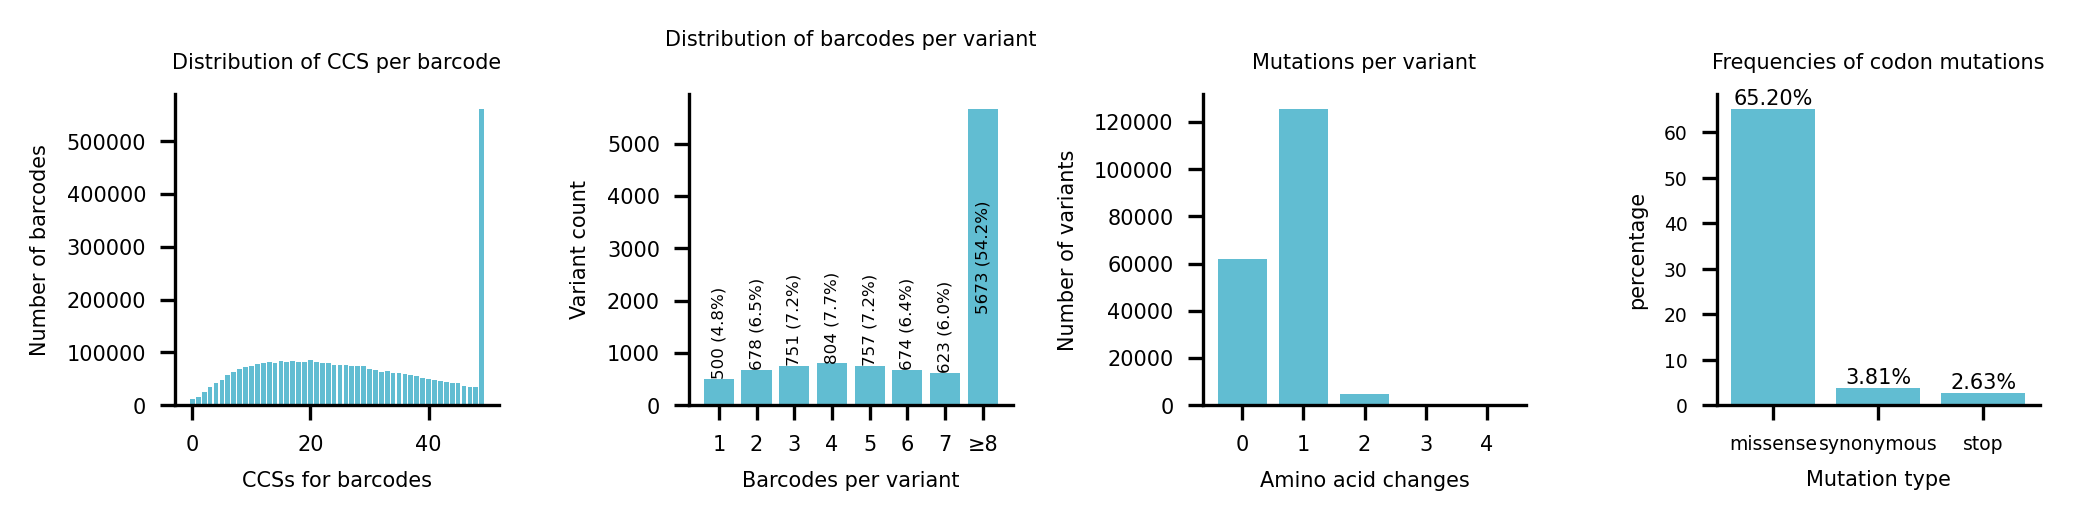

In [44]:
from collections import Counter

plt.figure(figsize=(7, 4.5), dpi=300)
plt.subplots_adjust(hspace=0.15, wspace=0.15)

ax = plt.subplot(3,4,1)

# Filter rows where 'retained' is True
filtered_data = processed_ccs.query('retained')

# Assign a column 'barcode_counts' with a value of 1
filtered_data = filtered_data.assign(barcode_counts=1)

# Group by 'library' and 'barcode', and count the occurrences
grouped_data = filtered_data.groupby(['library', 'barcode']).barcode_counts.transform('count')

# Clip the counts to the specified maximum value (max_count)
grouped_data = np.clip(grouped_data, None, max_count)

# Calculate the bar heights and positions
heights = grouped_data.value_counts().sort_index()
positions = np.arange(len(heights))




# Plot the barcode counts using ax.bar
ax.bar(positions, heights, width=0.8, color='#61BDD2')

# Set title and axis labels with font size
ax.set_title('Distribution of CCS per barcode', fontsize=5)
ax.set_xlabel('CCSs for barcodes', fontsize=5)
ax.set_ylabel('Number of barcodes', fontsize=5)
ax.tick_params(axis='both', labelsize=5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
# Show the plot
#plt.show()

ax = plt.subplot(3,4,2)

df=variants.barcode_variant_df.copy()

df_singles_aa_substitutions = df[(df['number_of_indels']==0) & (df['n_aa_substitutions']==1)]

# Step 1: Group by 'aa_substitutions' and count the occurrences
grouped_counts = df_singles_aa_substitutions['aa_substitutions'].value_counts()

# Step 2: Cap the counts at 8 (i.e., group all counts >= 8 together)
grouped_counts_capped = grouped_counts.clip(upper=8)

# Step 3: Count how many substitutions occurred exactly 1 time, 2 times, etc.
heights = grouped_counts_capped.value_counts().sort_index()

# Positions for each bar on the x-axis
positions = np.arange(1, len(heights) + 1)  # Adjusted to match x-ticks from 1 to 8

# 
bars=ax.bar(positions, heights, width=0.8, color='#61BDD2')

# Add text labels on top of each bar
total = sum(heights)

for i, bar in enumerate(bars):
    height = bar.get_height()
    percentage = height / total * 100
    label = f"{height} ({percentage:.1f}%)"

    # If it's the last bar, annotate halfway down
    if i == len(bars) - 1:
        y_pos = height * 0.5
        va = 'center'
    else:
        y_pos = height
        va = 'bottom'

    plt.text(bar.get_x() + bar.get_width()/2, y_pos,
             label, ha='center', va=va, rotation=90, fontsize=4)



# Set font size for everything
font_size = 5
ax.set_xlabel('Barcodes per variant', fontsize=font_size)
ax.set_ylabel('Variant count', fontsize=font_size)
ax.set_title('Distribution of barcodes per variant\n', fontsize=font_size)

# Set font size for tick labels
ax.tick_params(axis='both', labelsize=font_size)

# Ensure all x-ticks from 1 to 8 are shown
ax.set_xticks(np.arange(1, 9))
ax.set_xticklabels([str(i) for i in range(1, 8)] + ['≥8'])

# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Adjust layout
plt.tight_layout()


ax = plt.subplot(3,4,3)

# Assuming variants.barcode_variant_df.n_aa_substitutions is a list of values
data = variants.barcode_variant_df.n_aa_substitutions

# Count occurrences of each unique value
value_counts = Counter(data)

# Extract values and their counts
values = list(value_counts.keys())
counts = list(value_counts.values())

# Create a bar plot
plt.bar(values, counts, color='#61BDD2')

# Customize the plot if needed
plt.xlabel('Amino acid changes', fontsize=font_size)
plt.ylabel('Number of variants', fontsize=font_size)
plt.title('Mutations per variant', fontsize=font_size)

# Set x-tick positions and labels
plt.xticks(values,  fontsize=5)
ax.tick_params(axis='both', labelsize=font_size)

# Remove the top and left spines
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()

# Show the plot


ax = plt.subplot(3,4,4)

# Assuming variants.barcode_variant_df.variant_class is a list of values
data = variants.barcode_variant_df.variant_class

# Map '1 nonsynonymous' and '>1 nonsynonymous' to 'missense'
data_mapped = ['missense' if 'nonsynonymous' in item else item for item in data]

# Count occurrences of each unique value
value_counts = Counter(data_mapped)

# Extract values and their counts
values = list(value_counts.keys())[1:]
counts = list(value_counts.values())

# Calculate percentages
total_variants = sum(counts)
counts = counts[1:]
percentages = [count / total_variants * 100 for count in counts]

# Create a bar plot
bars = plt.bar(values, percentages, color='#61BDD2')

# Annotate the bars with percentages
for bar, percentage in zip(bars, percentages):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05, f'{percentage:.2f}%', ha='center', va='bottom', fontsize=5)

# Customize the plot if needed
plt.xlabel('Mutation type', size=5)
plt.ylabel('percentage', size=5)
plt.title('Frequencies of codon mutations', size=5)

# Set x-tick positions and labels
plt.xticks(values, fontsize=5)
ax.tick_params(axis='both', labelsize=4.5)

# Remove the top and left spines
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()

plt.savefig(f"{config['figs_dir']}/SuppFig1BCDE.pdf")
plt.show()

In [45]:
print ("number of missense single aa substitutions linked with only one barcode:")
print(len([i for i in grouped_counts.values if i == 1]))

print ("number of missense single aa substitutions linked with two or more barcodes:")
print(len([i for i in grouped_counts.values if i > 1]))

number of missense single aa substitutions linked with only one barcode:
500
number of missense single aa substitutions linked with two or more barcodes:
9960


## Completeness of mutation sampling

Examine how completely amino-acid mutations are sampled by the variants, looking at single-mutant variants only and all variants. The plot below shows that virtually every mutation is found in the library.

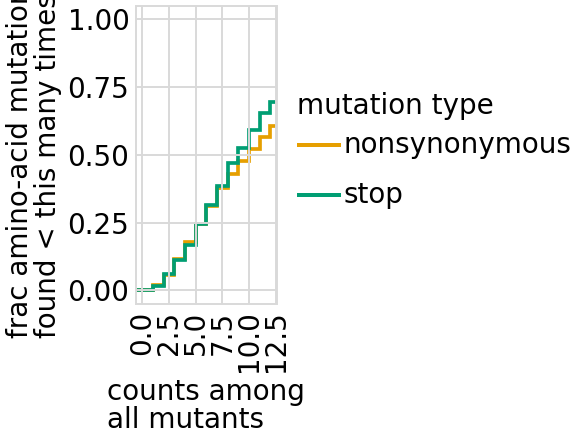

Saving plot to results/figures/variant_cumul_all_mut_coverage.pdf


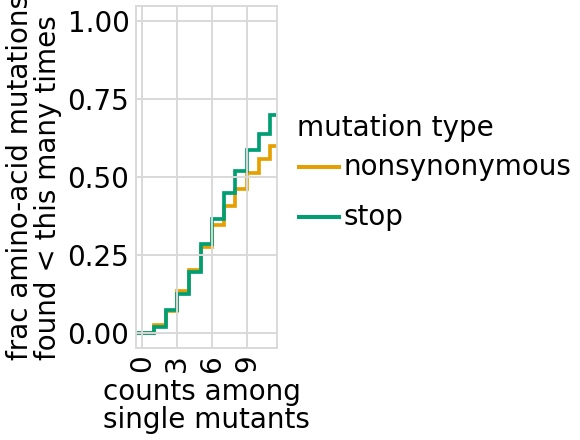

Saving plot to results/figures/variant_cumul_single_mut_coverage.pdf


In [46]:
for variant_type in ['all', 'single']:
    p = variants.plotCumulMutCoverage(variant_type, mut_type='aa', samples=None)
    _ = p.draw()
    display(p)
    plotfile = os.path.join(config['figs_dir'],
                            f"variant_cumul_{variant_type}_mut_coverage.pdf")
    print(f"Saving plot to {plotfile}")
    p.save(plotfile)

To get more quantitative view, determine how many mutations are found 0, 1, or >1 times both among single and all mutants for the primary target:

In [47]:
count_dfs = []
for variant_type in ['all', 'single']:
    i_counts = (variants.mutCounts(variant_type, mut_type='aa', samples=None)
                .assign(variant_type=variant_type)
                )
    count_dfs += [i_counts.assign(include_stops=True),
                  i_counts
                  .query('not mutation.str.contains("\*")', engine='python')
                  .assign(include_stops=False)
                  ]
    
display(HTML(
    pd.concat(count_dfs)
    .assign(count=lambda x: (numpy.clip(x['count'], None, 2)
                             .map({0: '0', 1: '1', 2:'>1'}))
            )
    .groupby(['variant_type', 'include_stops', 'library', 'count'])
    .aggregate(number_of_mutations=pd.NamedAgg(column='mutation', aggfunc='count'))
    .to_html()
    ))

## Mutation frequencies along gene

Plot the frequencies of mutations along the amplicon for both all variants and single-mutant / wildtype variants:

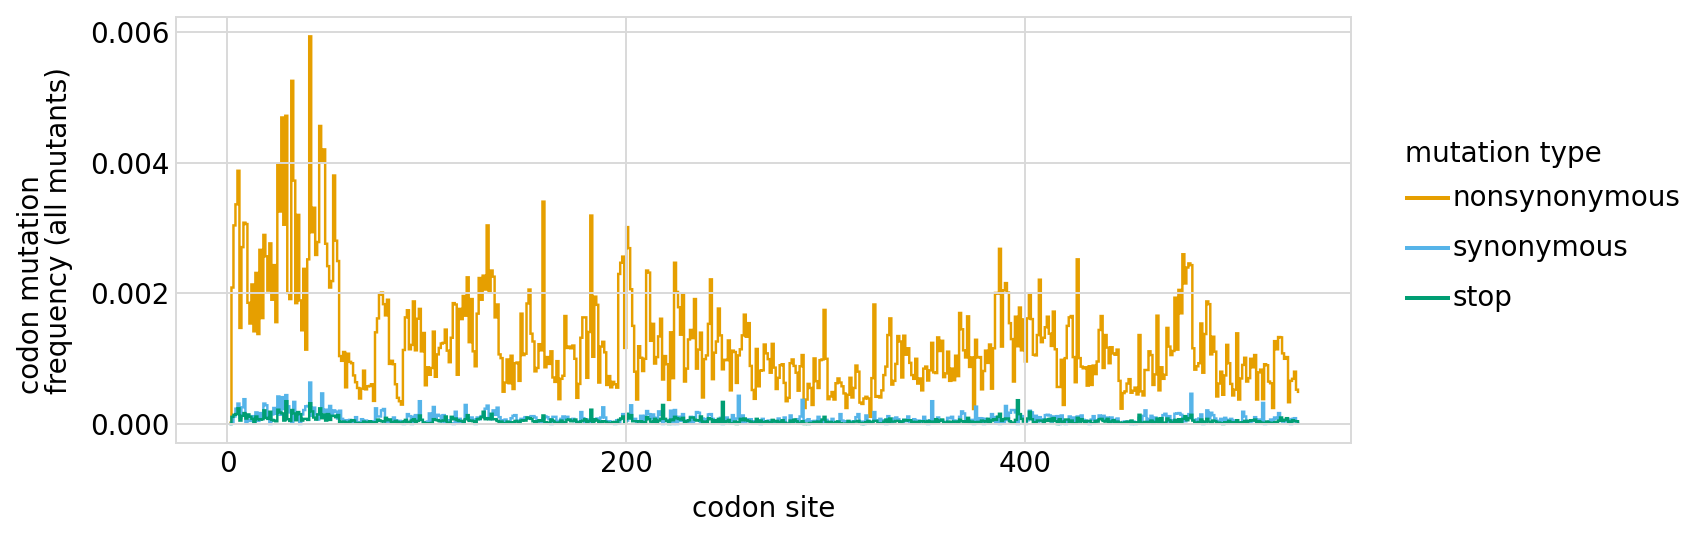

Saving plot to results/figures/variant_cumul_all_mut_Freqs.pdf


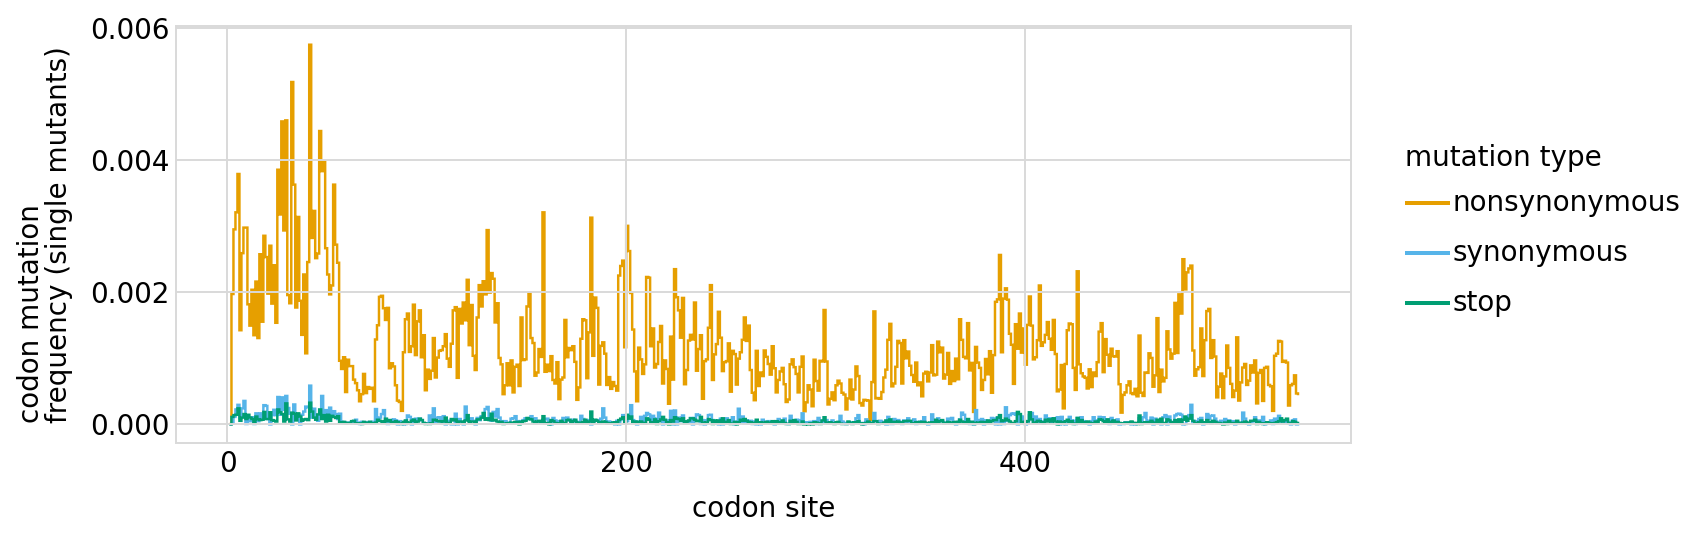

Saving plot to results/figures/variant_cumul_single_mut_Freqs.pdf


In [48]:
for variant_type in ['all', 'single']:
    p = variants.plotMutFreqs(variant_type, mut_type='codon', samples=None
                              , heightscale=1.5, widthscale=2.5)
    display(p)
    plotfile = os.path.join(config['figs_dir'],
                            f"variant_cumul_{variant_type}_mut_Freqs.pdf")
    print(f"Saving plot to {plotfile}")
    p.save(plotfile)

Using heat maps to examine the extent to which specific amino-acid or codon mutations are over-represented:

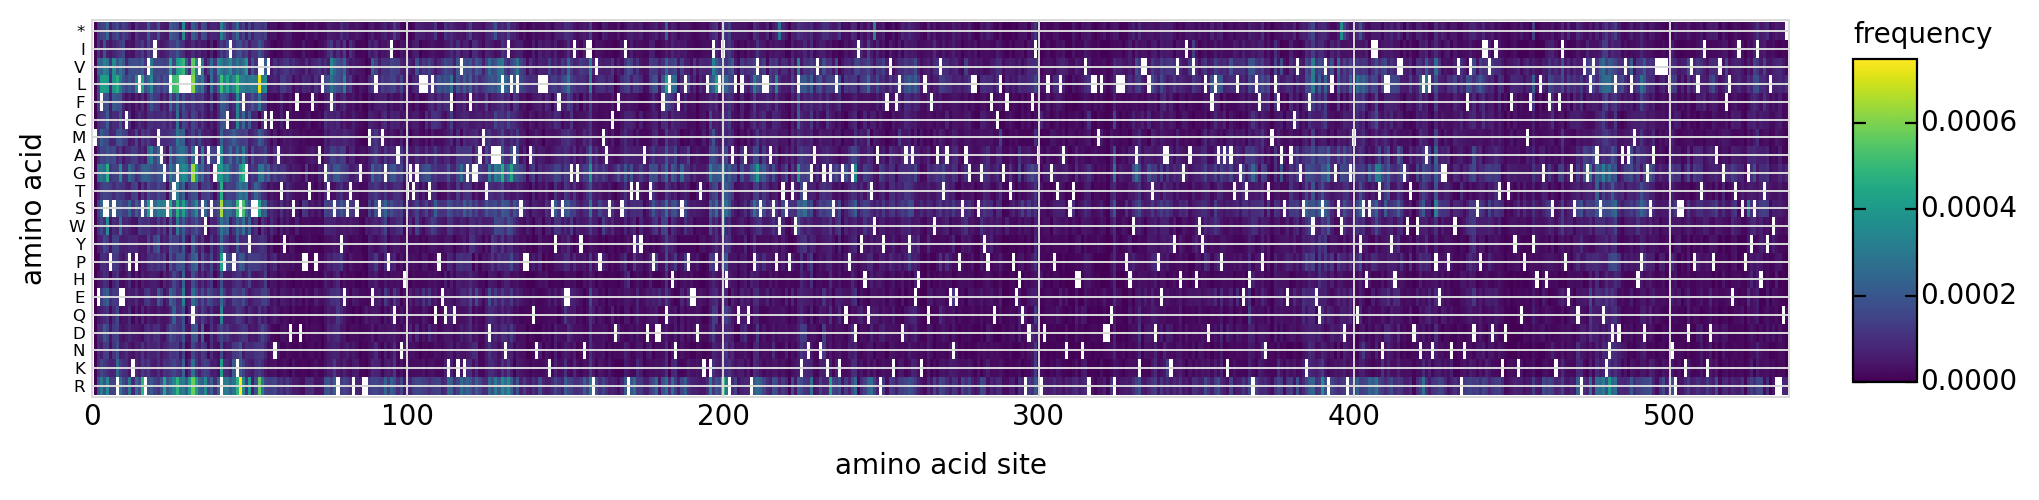

Saving plot to results/figures/variant_cumul_single_mut_heatmap.pdf


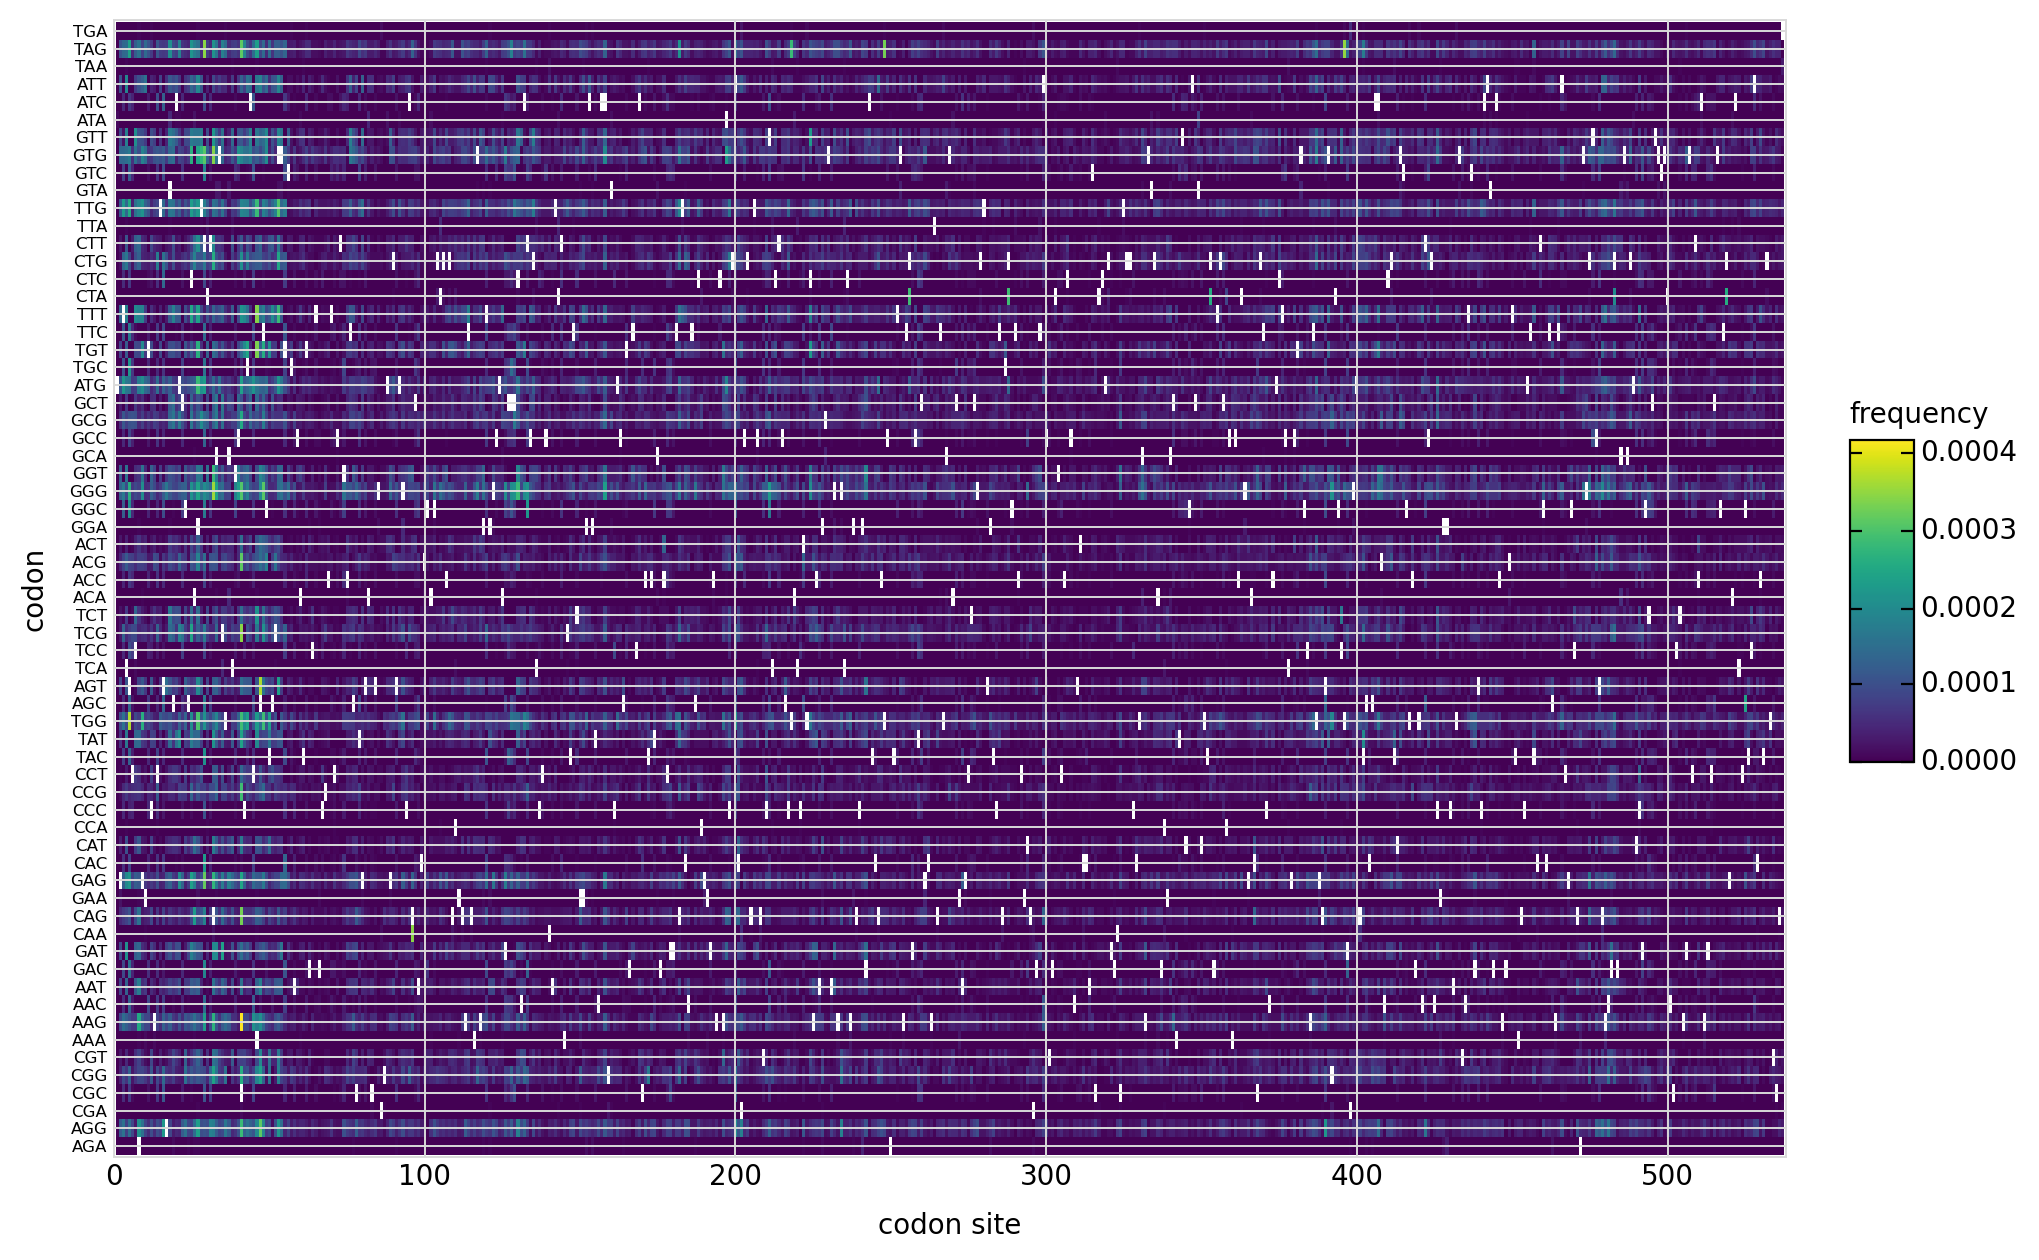

Saving plot to results/figures/variant_cumul_single_mut_heatmap.pdf


In [49]:
for mut_type in ['aa', 'codon']:
    p = variants.plotMutHeatmap('all', mut_type, samples=None, #libraries='all_only',
                                widthscale=2)
    p.draw()
    display(p)
    plotfile = os.path.join(config['figs_dir'],
                            f"variant_cumul_{variant_type}_mut_heatmap.pdf")
    print(f"Saving plot to {plotfile}")
    p.save(plotfile)

## Drop variants with indels

In [50]:
print (f" {len(variants.barcode_variant_df.query('number_of_indels>0'))}  variants with indels dropped from codon-variant table")

variants.barcode_variant_df = variants.barcode_variant_df.query('number_of_indels==0').reset_index(drop=True)

 2876  variants with indels dropped from codon-variant table


## Drop variants n_aa_substitutions more than 1 (multi variants)

In [51]:
print (f" {len(variants.barcode_variant_df .query('n_aa_substitutions>1'))}  variants with more than one substitutions dropped from codon-variant table")

variants.barcode_variant_df = variants.barcode_variant_df.query('n_aa_substitutions<2').reset_index(drop=True)

 4623  variants with more than one substitutions dropped from codon-variant table


## Reverse complement the barcode sequences
Barcodes sequenced in reverse complement direction in Flow-Seq, therefore, need to reverse complement the barcodes to Flow-Seq variant count


In [52]:
def reverse_complement(sequence):
    complements = {'A': 'T', 'C': 'G', 'G': 'C', 'T': 'A'}
    sequence = sequence[::-1]
    return sequence.translate(sequence.maketrans(complements))

variants.barcode_variant_df["barcode"] = (variants.barcode_variant_df["barcode"]
                                           .apply(reverse_complement))

## Write codon-variant table
The codon-variant table looks like this:

In [53]:
display(HTML(
    variants.barcode_variant_df
    .head()
    .to_html(index=False)
    ))

library,barcode,variant_call_support,number_of_indels,codon_substitutions,aa_substitutions,n_codon_substitutions,n_aa_substitutions,variant_class,aa_substitutions_c
GBA1,AAGCGGACTGCACGTCGTCTTTTTTTTTTT,1,0,,,0,0,wildtype,wildtype
GBA1,ACCATGTATCGACCCTATCATTTTTTTTTT,1,0,CGC78CAG,R78Q,1,1,1 nonsynonymous,R78Q
GBA1,TAAGTCGCTGCGCGGATGTCGTTTTTTTTT,13,0,,,0,0,wildtype,wildtype
GBA1,AGGCAAAACTGCTACTTGCCTGTTTTTTTT,8,0,AGC47TGG,S47W,1,1,1 nonsynonymous,S47W
GBA1,TTGTTTAGCTGTCAACCCCCCGTTTTTTTT,44,0,,,0,0,wildtype,wildtype


In [54]:
# Filter the DataFrame
df8 = variants.barcode_variant_df[['barcode', 'aa_substitutions', 'variant_class']]
df8 = df8[df8['variant_class'] != 'wildtype']
df8 = df8[df8['variant_class'] != 'synonymous']

# Randomly select 20 rows
df8_random = df8.sample(n=20, random_state=42)  # Setting random_state for reproducibility
df8_random[['barcode', 'aa_substitutions', 'variant_class']].to_csv(config['variants_dir'] + '/random_20_variants.csv', index=False)

In [55]:
print(f"Writing codon-variant table with reverse complemented barcodes to {config['codon_variant_table_file_bcRevCom']}")

variants.barcode_variant_df.to_csv(config['codon_variant_table_file_bcRevCom'], index=False)

Writing codon-variant table with reverse complemented barcodes to results/variants/codon_variant_table.csv


## Write full lengeth gene sequence for variants, this will be used as input for Enrich2

In [56]:
df_seq = variants.add_full_seqs(variants.barcode_variant_df)
df_seq.columns = [*df_seq.columns[:-1], 'variant']

print(f"Writing codon-variant table with full length gene sequences needed for Enrich2 input to {config['codon_variant_table_forEnrich2']}")

df_seq[['barcode','variant']].to_csv(config['codon_variant_table_forEnrich2'], sep ='\t', index=False, header=False)

Writing codon-variant table with full length gene sequences needed for Enrich2 input to results/variants/barcode_variant_enrich2.tab


### continue to flowSeq_analysis.ipynb for further analysis